In [1]:
# Q1 - Loading the Dataset

# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv(
    "train.txt",
    sep=";",
    names=["text", "emotions"]
)

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

First 10 Rows:
                                                text  emotions
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love

Dataset Shape:
(16000, 2)

Missing Values:
text        0
emotions    0
dtype: int64


In [2]:
# Q2 - Exploring Target Labels

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Display unique emotion labels
print("Unique Emotion Labels:")
print(df["emotions"].unique())

# Encode emotion labels
df["emotion_encoded"] = le.fit_transform(df["emotions"])

# Display emotion mapping
print("\nEmotion Mapping:")

for emotion in le.classes_:
    print(emotion, "=", le.transform([emotion])[0])

# Display first 10 rows
print("\nFirst 10 Rows:")
print(df.head(10))

Unique Emotion Labels:
['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']

Emotion Mapping:
anger = 0
fear = 1
joy = 2
love = 3
sadness = 4
surprise = 5

First 10 Rows:
                                                text  emotions  \
0                            i didnt feel humiliated   sadness   
1  i can go from feeling so hopeless to so damned...   sadness   
2   im grabbing a minute to post i feel greedy wrong     anger   
3  i am ever feeling nostalgic about the fireplac...      love   
4                               i am feeling grouchy     anger   
5  ive been feeling a little burdened lately wasn...   sadness   
6  ive been taking or milligrams or times recomme...  surprise   
7  i feel as confused about life as a teenager or...      fear   
8  i have been with petronas for years i feel tha...       joy   
9                                i feel romantic too      love   

   emotion_encoded  
0                4  
1                4  
2                0  
3                3  

In [3]:
# Q3 - Lowercasing

# Store original text for comparison
df["original_text"] = df["text"]

# Convert text to lowercase
df["text"] = df["text"].str.lower()

# Display 5 samples before and after lowercasing
print("Before and After Lowercasing:\n")

for i in range(5):
    print("Original :", df["original_text"][i])
    print("Lowercase:", df["text"][i])
    print()

Before and After Lowercasing:

Original : i didnt feel humiliated
Lowercase: i didnt feel humiliated

Original : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Lowercase: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Original : im grabbing a minute to post i feel greedy wrong
Lowercase: im grabbing a minute to post i feel greedy wrong

Original : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Lowercase: i am ever feeling nostalgic about the fireplace i will know that it is still on the property

Original : i am feeling grouchy
Lowercase: i am feeling grouchy



In [4]:
import string

# Function to remove punctuation
def remove_punctuation(text):
    for p in string.punctuation:
        text = text.replace(p, "")
    return text

# Store original text
df["before_punctuation"] = df["text"]

# Apply function
df["text"] = df["text"].apply(remove_punctuation)

# Display first 5 rows
for i in range(5):
    print("Before:", df["before_punctuation"][i])
    print("After :", df["text"][i])
    print()

Before: i didnt feel humiliated
After : i didnt feel humiliated

Before: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
After : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Before: im grabbing a minute to post i feel greedy wrong
After : im grabbing a minute to post i feel greedy wrong

Before: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
After : i am ever feeling nostalgic about the fireplace i will know that it is still on the property

Before: i am feeling grouchy
After : i am feeling grouchy



In [5]:
# Q5 - Removing Numbers

# Function to remove numbers
def remove_numbers(text):
    result = ""

    for char in text:
        if not char.isdigit():
            result = result + char

    return result

# Store text before removing numbers
df["before_numbers"] = df["text"]

# Apply function
df["text"] = df["text"].apply(remove_numbers)

# Display first 5 rows
print("Before and After Removing Numbers:\n")

for i in range(5):
    print("Before :", df["before_numbers"][i])
    print("After  :", df["text"][i])
    print()

Before and After Removing Numbers:

Before : i didnt feel humiliated
After  : i didnt feel humiliated

Before : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
After  : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Before : im grabbing a minute to post i feel greedy wrong
After  : im grabbing a minute to post i feel greedy wrong

Before : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
After  : i am ever feeling nostalgic about the fireplace i will know that it is still on the property

Before : i am feeling grouchy
After  : i am feeling grouchy



In [ ]:
# Q6 - Removing Emojis & Special Characters

# Function to remove emojis and special characters
def remove_emojis(text):
    return text.encode("ascii", "ignore").decode()

# Store original text
df["before_emojis"] = df["text"]

# Apply function
df["text"] = df["text"].apply(remove_emojis)

# Display first 5 rows
print("Before and After Removing Emojis:\n")

for i in range(5):
    print("Before :", df["before_emojis"][i])
    print("After  :", df["text"][i])
    print()

In [ ]:
# Q7 - Removing Stopwords
import nltk
from nltk.corpus import stopwords

# Download required resources
nltk.download("punkt")
nltk.download("stopwords")

# Load English stopwords
stop_words = stopwords.words("english")

# Function to remove stopwords
def remove_stopwords(txt):
    return " ".join([word for word in txt.split() if word not in stop_words])

# Store original text
df["before_stopwords"] = df["text"]

# Apply function
df["text"] = df["text"].apply(remove_stopwords)

# Display first 5 rows
print("Before and After Removing Stopwords:\n")

for i in range(5):
    print("Before :", df["before_stopwords"][i])
    print("After  :", df["text"][i])
    print()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yadao\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yadao\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Before and After Removing Stopwords:

Before : i didnt feel humiliated
After  : didnt feel humiliated

Before : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
After  : go feeling hopeless damned hopeful around someone cares awake

Before : im grabbing a minute to post i feel greedy wrong
After  : im grabbing minute post feel greedy wrong

Before : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
After  : ever feeling nostalgic fireplace know still property

Before : i am feeling grouchy
After  : feeling grouchy



In [7]:
# Q8 - Complete Text Cleaning Pipeline

import string

# Complete text cleaning function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = ''.join(char for char in text if not char.isdigit())

    # Remove emojis and special characters
    text = text.encode("ascii", "ignore").decode()

    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])

    return text

# Apply function on original text
df["cleaned_text"] = df["original_text"].apply(clean_text)

# Display first 10 rows
print("Original Text and Cleaned Text\n")

for i in range(10):
    print("Original :", df["original_text"][i])
    print("Cleaned  :", df["cleaned_text"][i])
    print()

Original Text and Cleaned Text

Original : i didnt feel humiliated
Cleaned  : didnt feel humiliated

Original : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Cleaned  : go feeling hopeless damned hopeful around someone cares awake

Original : im grabbing a minute to post i feel greedy wrong
Cleaned  : im grabbing minute post feel greedy wrong

Original : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Cleaned  : ever feeling nostalgic fireplace know still property

Original : i am feeling grouchy
Cleaned  : feeling grouchy

Original : ive been feeling a little burdened lately wasnt sure why that was
Cleaned  : ive feeling little burdened lately wasnt sure

Original : ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
Cleaned  : ive taking milligrams times recommended amount ive fallen asleep lot faster also f

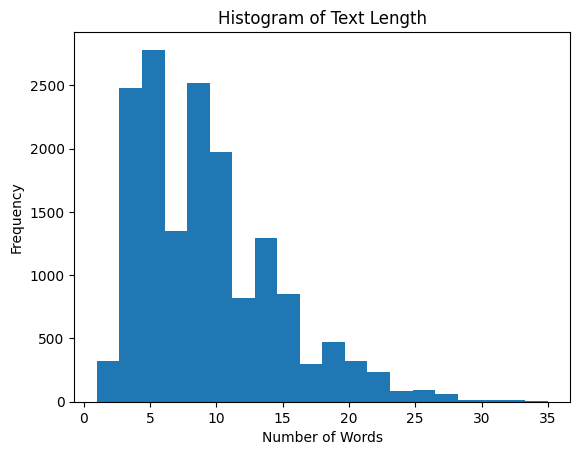

Average Text Length : 9.3530625
Minimum Text Length : 1
Maximum Text Length : 35


In [8]:
# Q9 - Text Length Analysis

import matplotlib.pyplot as plt

# Calculate number of words in cleaned text
df["text_length"] = df["cleaned_text"].apply(lambda x: len(x.split()))

# Plot histogram
plt.hist(df["text_length"], bins=20)
plt.title("Histogram of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Print statistics
print("Average Text Length :", df["text_length"].mean())
print("Minimum Text Length :", df["text_length"].min())
print("Maximum Text Length :", df["text_length"].max())

In [9]:
# Q10 - Mini Project

import pandas as pd
import string
import nltk
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords

# Download NLTK resources
nltk.download("punkt")
nltk.download("stopwords")

# Load Dataset
df = pd.read_csv("train.txt", sep=";", names=["text", "emotions"])

# Encode Emotion Labels
le = LabelEncoder()
df["emotion_encoded"] = le.fit_transform(df["emotions"])

# Load Stopwords
stop_words = stopwords.words("english")

# Complete Cleaning Function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = ''.join(char for char in text if not char.isdigit())

    # Remove emojis and special characters
    text = text.encode("ascii", "ignore").decode()

    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])

    return text

# Apply Cleaning
df["cleaned_text"] = df["text"].apply(clean_text)

# Save Cleaned Dataset
df.to_csv("cleaned_emotions.csv", index=False)

print("Cleaned dataset saved successfully.")

# Display Emotion Counts
print("\nEmotion Value Counts:\n")
print(df["emotions"].value_counts())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yadao\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yadao\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaned dataset saved successfully.

Emotion Value Counts:

emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
